In [34]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.stats import sigma_clip
from ccdproc import CCDData, combine, subtract_bias, flat_correct, trim_image
import astroscrappy
import warnings

import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.stats import sigma_clip
import sep
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import sep




from typing import List, Tuple

# Data loading

In [4]:
# fits_skimmer/skimmer.py

# fits_skimmer/skimmer.py

# fits_skimmer/skimmer.py

import glob
from astropy.io import fits
import os

# The single keyword that contains both image type (flat, dark, bias) 
# and band information (u, g, i) in your specific FITS files.
     

def skim_fits_files(directory='.', Keyword='OBJECT' , target_bands=['U', 'G', 'I'], exclusion_list=[]):
    """
    Skims through FITS files, applies an exclusion filter, and categorizes
    calibration frames (flat, dark, bias) by the specified photometry bands,
    using the OBJECT keyword for both type and band identification.

    Parameters:
    - keyword (str): header name for the filter e.g. 'OBJECT' 
    - directory (str): Path to the directory containing the FITS files. Defaults to the current directory.
    - target_bands (list): List of photometry bands to categorize (e.g., ['U', 'G', 'I']).
    - exclusion_list (list): List of strings. Files containing these strings
                             in their name will be skipped.

    Returns:
    - dict: A dictionary containing the categorized file paths.
    """
    # 1. Initialize the data structure
    # Band-specific lists for flats and any other band-specific files
    KEYWORD_COMPOUND = Keyword
    categorized_files = {band.upper(): {'flat': [], 'other': []} for band in target_bands}
    
    # Top-level lists for band-independent frames
    categorized_files['bias_frames'] = []
    categorized_files['dark_frames'] = []
    
    # Lists for unclassified/unwanted files
    categorized_files['unmatched'] = []
    categorized_files['excluded'] = []

    # Ensure bands are uppercase for robust matching
    target_bands = [b.upper() for b in target_bands]

    fits_files = glob.glob(os.path.join(directory, '*.fits'))
    print(f"Found {len(fits_files)} FITS files to check in '{directory}'.")

    for filename in fits_files:
        basename = os.path.basename(filename)
        
        # 2. Exclusion Check
        is_excluded = False
        for exclusion_str in exclusion_list:
            if exclusion_str in basename:
                categorized_files['excluded'].append(filename)
                is_excluded = True
                break
        
        if is_excluded:
            continue # Skip to the next file if excluded

        # 3. Process the FITS File
        try:
            with fits.open(filename, memmap=False) as hdul:
                header = hdul[0].header
                
                # Get the COMPOSITE value (e.g., 'flat_g  ' or 'bias  ')
                composite_value = str(header.get(KEYWORD_COMPOUND, 'UNKNOWN')).lower().strip()

                # --- 4. Categorize by Image Type ---
                
                # A. Band-Independent Frames (Dark/Bias)
                if 'bias' in composite_value or 'zero' in composite_value:
                    categorized_files['bias_frames'].append(filename)
                    continue # Finished with this file, move to the next

                elif 'dark' in composite_value:
                    categorized_files['dark_frames'].append(filename)
                    continue # Finished with this file, move to the next

                # B. Band-Dependent Frames (Flats and other science/standard frames)
                
                image_type = 'other'
                found_band = None
                
                # Check for FLAT frames
                if 'flat' in composite_value:
                    image_type = 'flat'
                
                # Identify the band for flats/other types by checking if a target band 
                # letter (u, g, i) is present in the object string
                for band in target_bands:
                     if band.lower() in composite_value:
                         found_band = band.upper()
                         break
                
                # Store flats and other band-specific frames
                if found_band:
                    categorized_files[found_band][image_type].append(filename)
                
                # If no target band was found or it's a completely unclassified type
                else:
                    categorized_files['unmatched'].append(f"{filename} (OBJECT: {composite_value})")


        except Exception as e:
            print(f"Error processing file {filename}: {e}")

    # 5. Print Summary and Return
    print(f"\n--- Skimming Complete ---")
    print(f"Total FITS files checked: {len(fits_files)}")
    print(f"Total files processed (not excluded): {len(fits_files) - len(categorized_files['excluded'])}")
    print(f"Total files excluded: {len(categorized_files['excluded'])}")
    
    return categorized_files



In [5]:
categorized_files = skim_fits_files(directory='./20250427/', Keyword= 'OBJECT' ,target_bands=['u', 'r', 'z'], exclusion_list=[])




Found 308 FITS files to check in './20250427/'.

--- Skimming Complete ---
Total FITS files checked: 308
Total files processed (not excluded): 308
Total files excluded: 0


In [6]:
#categorized_file sorted by different bands
categorized_files['R']['flat']


['./20250427/bs.FLAT.0038.fits',
 './20250427/bs.FLAT.0039.fits',
 './20250427/bs.FLAT.0036.fits',
 './20250427/bs.FLAT.0040.fits',
 './20250427/bs.FLAT.0037.fits']

In [7]:
categorized_files

{'U': {'flat': ['./20250427/bs.FLAT.0043.fits',
   './20250427/bs.FLAT.0042.fits',
   './20250427/bs.FLAT.0045.fits',
   './20250427/bs.FLAT.0044.fits',
   './20250427/bs.FLAT.0041.fits'],
  'other': ['./20250427/bs.OBJECT.0184.fits',
   './20250427/bs.OBJECT.0169_amp8_reduced.fits',
   './20250427/bs.OBJECT.0242.fits',
   './20250427/bs.OBJECT.0235_amp6_reduced.fits',
   './20250427/bs.OBJECT.0235_amp1_reduced.fits',
   './20250427/bs.OBJECT.0215.fits',
   './20250427/bs.OBJECT.0203.fits',
   './20250427/bs.OBJECT.0192.fits',
   './20250427/bs.OBJECT.0254.fits',
   './20250427/bs.OBJECT.0229_amp1_reduced.fits',
   './20250427/bs.OBJECT.0239.fits',
   './20250427/bs.OBJECT.0229_amp6_reduced.fits',
   './20250427/bs.OBJECT.0188.fits',
   './20250427/bs.OBJECT.0219.fits',
   './20250427/bs.OBJECT.0258.fits',
   './20250427/bs.OBJECT.0223.fits',
   './20250427/bs.OBJECT.0235.fits',
   './20250427/bs.OBJECT.0234.fits',
   './20250427/bs.OBJECT.0229_amp7_reduced.fits',
   './20250427/bs.OBJ

In [9]:
import numpy as np
from typing import List
from astropy.io import fits








In [10]:
categorized_files['R']['other'][1:2]

['./20250427/bs.OBJECT.0079.fits']

In [11]:
def find_bad_columns(ccd_data: np.ndarray, saturation_threshold: float, black_column_threshold: float,\
sf: float, bf: float) -> List[int]:
    """
    Identifies columns that are either at least half saturated or containing > 25% bad pixels.

    A column is considered "bad" if more than half of its pixels are either:
    1. Greater than or equal to the saturation_threshold (saturated column).
    2. Less than or equal to the black_column_threshold (black or "dead" column).

    Args:
        ccd_data (np.ndarray): A 2D NumPy array representing the CCD image.
        saturation_threshold (float): The value at or above which a pixel
                                      is considered saturated.
        black_column_threshold (float): The value at or below which a pixel
                                        is considered part of a "black" column.
        sf (float): The fraction threshold for saturated pixels in a column (e.g., 0.5 for 50%).
        df (float): The fraction threshold for black pixels in a column (e.g., 0.25 for 25%).

    Returns:
        List[int]: A list of column indices that are identified as bad.
    """
    # Get the number of rows and columns in the image
    rows, cols = ccd_data.shape
    bad_columns = []
    
    print(f"Checking {cols} columns for partially saturated or zero-level pixels...")

    # Iterate through each column
    for j in range(cols):
        # Extract the current column
        column_data = ccd_data[:, j]
        
        # Count the number of pixels meeting the criteria
        saturated_pixel_count = np.sum(column_data >= saturation_threshold)
        black_pixel_count = np.sum(column_data <= black_column_threshold)
        
        # Check if more than half of the pixels are saturated or black
        is_partially_saturated = saturated_pixel_count > rows* sf
        is_partially_black = black_pixel_count > rows * bf

        if is_partially_saturated or is_partially_black:
            bad_columns.append(j)
            if is_partially_saturated:
                print(f"  - Column {j} is partially saturated ({saturated_pixel_count}/{rows} pixels).")
            if is_partially_black:
                print(f"  - Column {j} is partially black ({black_pixel_count}/{rows} pixels).")
        # else:
            # print(f"  - Column {j} is not a bad column.")

    return bad_columns

def create_bad_pixel_map(shape: tuple, bad_columns: List[int]) -> np.ndarray:
    """
    Creates a 2D binary bad pixel map.

    The map will have the same dimensions as the original image and will be
    initialized with zeros. Columns specified as "bad" will be set to 1.

    Args:
        shape (tuple): The (rows, columns) shape of the original image.
        bad_columns (List[int]): A list of column indices to flag as bad.

    Returns:
        np.ndarray: A 2D NumPy array representing the bad pixel map.
    """
    # Create an array of zeros with the specified shape
    bad_map = np.zeros(shape, dtype=int)
    
    # Iterate through the list of bad column indices and set those columns to 1
    for col_index in bad_columns:
        bad_map[:, col_index] = 1

    return bad_map


def mask_bad_columns(ccd_data: np.ndarray, bad_columns: List[int]) -> np.ndarray:
    """
    Masks bad columns by setting their pixel values to NaN.

    This function makes a copy of the data and replaces the values in each
    bad column with np.nan.

    Args:
        ccd_data (np.ndarray): The 2D NumPy array representing the CCD image.
        bad_columns (List[int]): A list of column indices to mask.

    Returns:
        np.ndarray: A new NumPy array with the bad columns masked.
    """
    # Create a copy to avoid modifying the original data
    masked_data = np.copy(ccd_data)
    
    for j in bad_columns:
        masked_data[:, j] = np.nan
            
    return masked_data


def process_and_save_calibrated_image(calibrated_image: np.ndarray, bad_columns: List[int],amp_num: float, output_path: str = './'):
    """
    Processes a calibrated image by masking bad columns and saving the results.

    This function generates a bad pixel map, masks the bad columns in the image,
    visualizes the results, and saves the masked image and the bad pixel map
    as FITS files.

    Args:
        calibrated_image (np.ndarray): The calibrated 2D NumPy array (e.g., Final_sci).
        bad_columns (List[int]): A list of column indices to mask.
        output_path (str): The directory path to save the output files.
    """
    # Create the bad pixel map
    bad_pixel_map = create_bad_pixel_map(calibrated_image.shape, bad_columns)

    # Mask the bad columns in the calibrated image
    masked_image = mask_bad_columns(calibrated_image, bad_columns)

    # --- Visualize the results ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    # Display the original calibrated image (before masking)
    
    axes[0].set_title("Mask Calibrated Image")
    # Display the bad pixel map overlaid on the masked image
    axes[0].imshow(masked_image, cmap='hot')
    axes[1].set_title("Masked Image with Bad Pixel Map")
    axes[1].imshow(bad_pixel_map, cmap='hot', alpha=0.5, vmin=0, vmax=1)
    plt.show()
    
    # --- Save the files to FITS format ---
    # To save the masked image
    masked_hdu = fits.PrimaryHDU(masked_image)
    masked_hdul = fits.HDUList([masked_hdu])
    masked_hdul.writeto(f'{output_path}/masked_image_ampnum_'+str(amp_num)+'.fits', overwrite=True)
    print(f"Saved masked image to: {output_path}/masked_image_ampnum_"+str(amp_num)+'.fits')

    # To save the bad pixel map
    map_hdu = fits.PrimaryHDU(bad_pixel_map)
    map_hdul = fits.HDUList([map_hdu])
    map_hdul.writeto(f'{output_path}/bad_pixel_map_ampnum_'+str(amp_num)+'.fits', overwrite=True)
    print(f"Saved bad pixel map to: {output_path}/bad_pixel_map_ampnum_"+str(amp_num)+'.fits')

    return bad_pixel_map, masked_image

In [12]:

def diff_amp(amp_num: int, bias_filesf: List[str], dark_filesf: List[str], flat_filesf: List[str], sciences: List[str]):
    """
    Loads astronomical image data from bias, flat, dark FITS files for a specific amplifier.

    This function reads FITS files for biases, darks, flats, and science images,
    extracts the data from a specified amplifier (HDU) within each file, and
    returns the data in separate lists.

    Args:
        amp_num (int): The HDU index (amplifier number) to extract from each FITS file.
        bias_filesf (List[str]): A list of file paths for bias frames.
        dark_filesf (List[str]): A list of file paths for dark frames.
        flat_filesf (List[str]): A list of file paths for flat-field frames.
        sciences (List[str]): A list of file paths for science images.

    Returns:
        Tuple[List[np.ndarray], ...]: A tuple containing four lists of NumPy arrays:
                                      (biases, darks, flats, sciencesf)
    """
    # Initialize lists to store the image data for each file type
    biases = [0] * len(bias_filesf)
    darks = [0] * len(dark_filesf)
    flats = [0] * len(flat_filesf)
    sciencesf = [0] * len(sciences)
    
    # Loop through each bias and dark file to load the data
    # Note: Both bias and dark loops are combined in your original code.
    for ii in range(len(bias_filesf)):
        # Open the bias FITS file
        file = fits.open(bias_filesf[ii])
        # Extract the data from the specified amplifier (HDU) and store it, subtracted by the overscan
        biases[ii] = file[amp_num].data-np.median(file[amp_num].data[:,2040:2060])
        #print (np.median(file[amp_num].data[:,2040:2060]))
        
        # Open the dark FITS file and do the same
    for jj in range(len(dark_filesf)):
        # Open the dark FITS file
        file = fits.open(dark_filesf[jj])
        # Extract the data from the specified amplifier (HDU) and store it,subtracted by the overscan
        darks[jj] = file[amp_num].data-np.median(file[amp_num].data[:,2040:2060])
        #print (np.median(file[amp_num].data[:,2040:2060]))

    # Loop through each flat file to load the data
    for kk in range(len(flat_filesf)):
        # Open the flat FITS file
        file = fits.open(flat_filesf[kk])
        # Extract the data from the specified amplifier (HDU) and store it, subtracted by the overscan
        flats[kk] = file[amp_num].data-np.median(file[amp_num].data[:,2040:2060])
        #print (np.median(file[amp_num].data[:,2040:2060]))

    # Loop through each science file to load the data
    for k in range(len(sciences)):
        # Open the science FITS file
        file = fits.open(sciences[k])
        # Extract the data from the specified amplifier (HDU) and store it,, subtracted by the overscan
        sciencesf[k] = file[amp_num].data-np.median(file[amp_num].data[:,2040:2060])
        #print (np.median(file[amp_num].data[:,2040:2060]))

    # Return the lists of loaded image data
    return biases, darks, flats, sciencesf




def data_reduction(
    ext: int,
    bias: np.ndarray,
    flats: np.ndarray,
    sci,
    sci_paths: List[str],
    plot_normalize_flat: bool = False,
    plot_final_sci: bool = False,
    write_output: bool = True
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Performs basic flat-field, bias, and dark correction on astronomical images.

    Args:
        ext (int): FITS extension number for science data.
        Master_bias (np.ndarray): Median bias frame.
        Master_dark (np.ndarray): Median dark frame.
        flats (List[np.ndarray]): List of flat frames.
        sci_paths (List[str]): List of science FITS file paths.
        plot_normalize_flat (bool): If True, plots the normalized master flat frame.
        plot_final_sci (bool): If True, plots the final reduced science image.
        write_output (bool): If True, writes the reduced science image to FITS.

    Returns:
        Tuple[np.ndarray, np.ndarray]: The normalized flat and one example reduced science image.
    """
    # Create a Master Flat frame
    
    
   
    # Create a Master Science frame
    # The master science frame is the median of all science images.
    Master_science = np.median(sci, axis=0)
    
    # Calculate dark current correction factor
    # This factor scales the dark frame to match the exposure time of the science frame.
    #correction_factor = np.mean(Master_science) / np.mean(Master_dark)
    
    # Create a Normalized Flat frame
    
    # The normalized flat has the dark signal removed and is scaled to unity (1.0).
    Normalized_flat = (Master_flat - Master_bias) / np.median(Master_flat)
    
    

    if plot_normalize_flat:
        plt.figure()
        plt.title('Normalized Flat')
        plt.imshow(Normalized_flat, vmax=5, origin='lower')
        plt.colorbar()

    reduced_sci = []
    for sci_path in sci_paths:
        print (sci_paths)
        with fits.open(sci_path) as hdul:
            sci_data = hdul[ext].data.astype(float)
            
            hdr = hdul[ext].header.copy()

            # Correction factor for dark scaling to science frame
            #sci_correction_factor = np.median(sci_data) / np.median(Master_dark)
            final = (sci_data - Master_bias) / Normalized_flat
            
            reduced_sci.append((final, hdr))
            if plot_final_sci:
                plt.figure()
                plt.title(f'Final Reduced Science Image: {sci_path}')
                plt.imshow(final, vmax=np.mean(final)*2, origin='lower')
                plt.colorbar()

            if write_output:
                outname = sci_path.replace(".fits", f"_amp{ext}_reduced.fits")
                fits.writeto(outname, final, hdr, overwrite=True)

    if plot_normalize_flat or plot_final_sci:
        plt.show()

    # Return the normalized flat and the last reduced science image for checking
    return Normalized_flat, reduced_sci[-1][0] if reduced_sci else None


def flat_reduction_b(biases, darks, flats, plot_master_bias: bool = False, plot_unbias_dark: bool = False, plot_master_flat: bool = False):
     
    """
    Performs basic flat-field and bias correction on astronomical images.

    This function computes master flat frames by taking the median
    of each input list. It then normalizes the flat frame and uses it to correct the
    science image. It can also optionally plot the master frames and the final science image.

    Args:
        biases (List[np.ndarray]): A list of bias frames.
        darks (List[np.ndarray]): A list of dark frames.
        flats (List[np.ndarray]): A list of flat-field frames.
        sci (List[np.ndarray]): A list of science images.
        plot_master_bias (bool): If True, plots the master bias frame.
        plot_master_flat (bool): If True, plots the normalized master flat frame.
        plot_final_sci (bool): If True, plots the final reduced science image.

    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray]: A tuple containing the master flat,
                                                   normalized flat.
    """
    # 1. Create a Master Bias frame
    # A master bias is the median of all bias frames, which removes most of the random noise.
    Master_bias = np.median(biases, axis=0)

    if plot_master_bias:
        plt.figure()
        plt.title('Master Bias')
        plt.imshow(Master_bias, vmax=1200, origin='lower')

    # 2. Create Master Dark and Unbiased Dark frames
    # A master dark is the median of all dark frames, which captures thermal signal.
    Master_dark = np.median(darks, axis=0)
    

    # Remove the bias signal from the master dark frame
    Unbiased_dark = Master_dark - Master_bias
    if plot_unbias_dark:
        plt.figure()
        plt.title('Unbiased Dark')
        plt.imshow(Unbiased_dark, vmax=1200, origin='lower')

    # 3. Create a Master Flat frame
    # A master flat is the median of all flat frames, which accounts for pixel sensitivity.
    Master_flat = np.median(flats, axis=0)
    
    if plot_master_flat:
        plt.figure()
        plt.title('Master Flat')
        plt.imshow(Master_flat, vmax=2.5e4, origin='lower')

    return Master_bias, Master_dark, Unbiased_dark, Master_flat

In [13]:
from scipy.optimize import curve_fit

def radial_profile(data, center):
    y, x = np.indices(data.shape)
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)
    r_max = int(r.max()) + 1
    radial_mean = np.array([data[r == i].mean() for i in range(r_max)])
    return np.arange(r_max), radial_mean

def gaussian(r, a, mu, sigma, c):
    return a * np.exp(-(r-mu)**2/(2*sigma**2)) + c

def sep_run_2(mask_data, threshold, cutout_size=15):
    data = mask_data.astype(np.float32)
    mask = data > (np.median(data) + 5 * np.std(data))
    bkg = sep.Background(data, bw=64, bh=64, fw=3, fh=3, mask=mask)
    data_sub = data - bkg
    objects, segmap = sep.extract(data_sub, thresh=threshold, err=bkg.globalrms, segmentation_map=True, minarea=20)

    print("Number of objects detected:", len(objects))
    #print(objects.dtype.names)  # show available columns (x, y, flux, etc.)

    fwhm_sep = 2.355 * np.sqrt(objects['a'] * objects['b'])

    fwhm_radial = []
    flux_in_fwhm = []
    flux_peak_ratio = []
    sep_flags = []
    for i in range(len(objects)):
        x, y = int(objects['x'][i]), int(objects['y'][i])
        sep_flags.append(objects['flag'][i])
        # Check boundaries for cutout
        if (y-cutout_size < 0 or y+cutout_size > data_sub.shape[0] or
            x-cutout_size < 0 or x+cutout_size > data_sub.shape[1]):
            fwhm_radial.append(np.nan)
            flux_in_fwhm.append(np.nan)
            flux_peak_ratio.append(np.nan)
            continue
        cutout = data_sub[y-cutout_size:y+cutout_size, x-cutout_size:x+cutout_size]
        rp_r, rp_flux = radial_profile(cutout, (cutout_size, cutout_size))
        try:
            popt, _ = curve_fit(gaussian, rp_r, rp_flux,
                                p0=[rp_flux.max(), 0, 2, np.median(rp_flux[-5:])])
            sigma = abs(popt[2])
            fwhm = 2.355 * sigma
            fwhm_radial.append(fwhm)
        except Exception:
            fwhm_radial.append(np.nan)
            flux_in_fwhm.append(np.nan)
            flux_peak_ratio.append(np.nan)
            continue
        # Flux inside FWHM radius
        yy, xx = np.indices(cutout.shape)
        rr = np.sqrt((xx - cutout_size)**2 + (yy - cutout_size)**2)
        mask_fwhm = rr <= fwhm_radial[-1] if not np.isnan(fwhm_radial[-1]) else np.zeros_like(rr, dtype=bool)
        flux_fwhm = cutout[mask_fwhm].sum()
        flux_in_fwhm.append(flux_fwhm)
        # Peak pixel
        peak_pix = cutout.max()
        ratio = flux_fwhm / peak_pix if peak_pix != 0 else np.nan
        flux_peak_ratio.append(ratio)

    e = 1 - objects['b'] / objects['a']

    return data_sub, objects, fwhm_sep, fwhm_radial, flux_in_fwhm, flux_peak_ratio, e




# Main Code for calling the function and extracting the stars

[[ 9.22769818e-01  1.12119061e+00  1.18914963e+00 ...  0.00000000e+00
  -2.21798341e-05 -8.87193364e-05]
 [ 1.00692011e+00  1.10544293e+00  1.12147895e+00 ... -6.65395023e-05
  -1.10899170e-04  8.87193364e-05]
 [ 9.62782238e-01  9.86802999e-01  9.87468394e-01 ... -2.21798341e-05
  -1.10899170e-04  8.87193364e-05]
 ...
 [ 6.20658297e-01  6.47074480e-01  6.49115025e-01 ...  8.18435878e-03
   7.62986293e-03  8.45051679e-03]
 [ 6.35674045e-01  6.87242159e-01  7.08046844e-01 ...  5.52277869e-03
   5.23444085e-03  5.52277869e-03]
 [ 5.92068491e-01  7.12904227e-01  7.43534578e-01 ...  6.29907288e-03
   5.76675686e-03  6.16599388e-03]]
['./20250427/bs.OBJECT.0079.fits']
Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 446 is partially black (1616/4080 pixels).
  - Column 447 is partially black (1616/4080 pixels).
  - Column 771 is partially saturated (4080/4080 pixels).
  - Column 772 is partially saturated (4080/4080 pixels).


<ipython-input-12-1bce8d1c46f2>:130: RuntimeWarning: divide by zero encountered in divide
  final = (sci_data - Master_bias) / Normalized_flat


  - Column 1709 is partially saturated (4080/4080 pixels).
  - Column 1710 is partially saturated (4080/4080 pixels).
  - Column 1711 is partially saturated (4080/4080 pixels).
  - Column 1712 is partially saturated (4057/4080 pixels).
  - Column 1839 is partially saturated (4080/4080 pixels).
  - Column 1861 is partially saturated (4080/4080 pixels).
  - Column 1862 is partially saturated (4080/4080 pixels).
  - Column 1863 is partially saturated (4080/4080 pixels).
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 2044 is partially black (4080/4080 pixels).
  - Column 2045 is partially black (4080/4080 pixels).
  - Column 2046 is partially black (4080/4080 pixels).
  - Column 2047 is partially black (4080/4080 pixels).
  - Column 2048 is partially black (4080/4080 pixels).
  - Column 2049 is partially blac

TypeError: 'AxesSubplot' object is not subscriptable

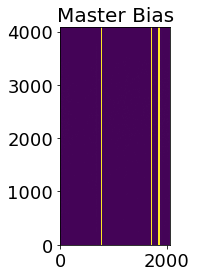

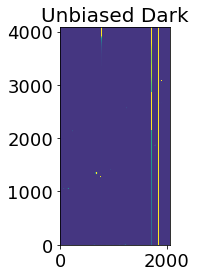

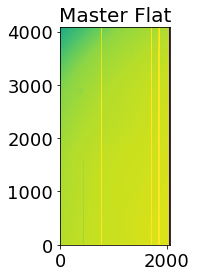

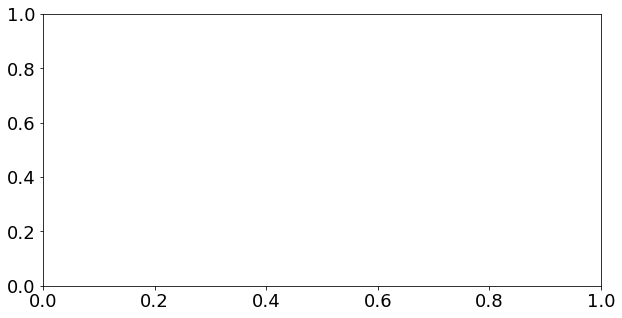

In [48]:
amptot = 9
fwhmt = []
flux_t = []
flux_r=[]
et=[]
threshold = 5
objtot = []
for ii in range(1,amptot):
    biases, darks, flats, sciencesf = diff_amp(ii, categorized_files['bias_frames'],categorized_files['dark_frames'], categorized_files['R']['flat'], categorized_files['R']['other'][1:2])
    #print (np.median(biases))
    Master_bias, Master_dark, Unbiased_dark, Master_flat  = flat_reduction_b(biases, darks, flats, plot_master_bias= True, plot_unbias_dark = True, plot_master_flat = True)
    Normalized_flat, Final_sci = Normalized_flat, Final_scii=data_reduction(ii,Master_bias,  Master_flat,sciencesf[0],  categorized_files['R']['other'][1:2],plot_normalize_flat=False, plot_final_sci= False,write_output =True)
#for ii in range(1,num_amp+1):
    bad_columns = find_bad_columns(Master_flat, np.median(Master_flat)+np.std(Master_flat)\
                 ,np.median(Master_flat)-4*np.std(Master_flat), 0.25, 0.2)
    
    scit = fits.open('/Users/Jenny/projects/observation/bok/20250427/bs.OBJECT.0079_amp'+str(ii)+'_reduced.fits')
    
    masked_d = mask_bad_columns(scit[0].data, bad_columns) 
    
    bad_pixel_map = create_bad_pixel_map(Master_flat.shape, bad_columns)
    
    

    # --- Visualize the bad pixel map ---
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))

    # Display the original image
    axes[0].imshow(masked_d, cmap='hot',vmin=0, vmax=4000)
    axes[0].set_title("Maksed Image")
    data_sub, objects, fwhm_sep, fwhm_radial, flux_in_fwhm, flux_peak_ratio, e = sep_run_2(masked_d,threshold)
    region_filename = f"amp{ii}_sources_ellipse.reg"
    with open(region_filename, "w") as reg:
        reg.write("# Region file format: DS9 version 4.1\n")
        reg.write("image\n")
        for i in range(len(objects)):
            x = objects['x'][i]
            y = objects['y'][i]
            a = objects['a'][i]
            b = objects['b'][i]
            theta = objects['theta'][i] * 180. / np.pi  # DS9 expects degrees
            reg.write(f"ellipse({x},{y},{a},{b},{theta})\n")
   
    et.append(e)
    fwhmt.append(fwhm_radial)
    flux_t.append(flux_in_fwhm)
    flux_r.append(flux_peak_ratio)
    objtot.append(objects)
    
    
    
    #segm = detect_sources(masked_d[20:4060,105:], threshold, npixels=5)
    
    

# Creating Final Table for Investigation

In [46]:


tables = [Table(obj) for obj in objtot]

# Suppose you want to label subsets 0,1,...,8
labels = []
for i, tab in enumerate(tables):
    labels += [i] * len(tab)

# Stack tables
all_objects = vstack(tables)




# Add subset label column
all_objects['subset_id'] = labels

# Add subset label column
all_objects['FWHM'] = np.concatenate(fwhmt)
all_objects['e'] =np.concatenate(et)
all_objects['flux_ratio'] =np.concatenate(flux_r)

In [47]:
all_objects

thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2,y2,xy,errx2,erry2,errxy,a,b,theta,cxx,cyy,cxy,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag,subset_id,FWHM,e,flux_ratio
float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64
125.01118469238281,23,23,136,141,0,3,138.60044152566698,1.037569653429347,1.6225626102984965,0.887566792364727,-0.008120019445982951,0.0001678925535751106,8.273272085766382e-05,1.0548728153712795e-05,1.2738337516784668,0.9420600533485413,-0.011045911349356174,0.616337239742279,1.1267273426055908,0.011277281679213047,15373.79296875,17800.681640625,1602.5516357421875,2688.00146484375,139,1,139,0,2,0,nan,0.26045290281621447,nan
125.01118469238281,34,34,1217,1226,0,3,1221.566032650902,0.9862917505523461,4.25969430316038,1.0225709543762385,0.4231692560901168,0.0009320406208812018,0.00021808275781720743,0.00010385288013065082,2.077040672302246,0.9839547276496887,0.12786181271076202,0.24482353031635284,1.0198543071746826,-0.20263002812862396,12024.7900390625,14534.486328125,960.8082885742188,1929.876220703125,1221,0,1221,0,2,0,nan,0.526270842564172,nan
125.01118469238281,60,59,263,270,11,19,266.57818138811245,15.048192162912542,2.194951836196939,2.7158117942269193,-0.13610340685093547,5.921220301043416e-05,7.330362338512285e-05,5.241769666460663e-08,1.658080816268921,1.47021484375,-1.3300104141235352,0.45701104402542114,0.3693618178367615,0.04580638185143471,51922.48046875,52735.3515625,3318.681396484375,4553.10302734375,267,15,267,15,0,0,3.452564268301334,0.11330326644853439,10.54139232635498
125.01118469238281,39,36,1429,1436,16,22,1432.3519534694412,19.5137366652775,2.4499053079477378,2.123794917491347,0.3502768570575441,0.0005605187352031258,0.0004475423795945635,0.0001111603310637559,1.6349982023239136,1.3785794973373413,0.5675622820854187,0.41803672909736633,0.4822266101837158,-0.13789334893226624,12604.4912109375,13150.9140625,699.0096435546875,889.286376953125,1432,19,1432,20,0,0,3.981992981693865,0.15683118465947554,15.137201309204102
125.01118469238281,134,126,507,519,29,42,513.3947599511966,35.47858309045561,2.9784348911538316,3.5824328123279514,-0.15425245810906318,8.935791599955643e-06,1.0479209513494614e-05,-6.020577313101935e-08,1.9025105237960815,1.715028166770935,-1.3346824645996094,0.3364971876144409,0.279763787984848,0.028977803885936737,304269.9375,305114.21875,16611.50390625,21701.40625,514,35,514,35,0,0,3.3559707560958323,0.09854471482820637,12.051426887512207
125.01118469238281,103,96,84,94,48,59,89.23184435602185,53.33326749493097,2.741330431685313,3.2696771129966145,-0.15996337395626625,1.7214165786075255e-05,1.9443134593800738e-05,-2.5379064150644994e-07,1.8205311298370361,1.6421552896499634,-1.2985605001449585,0.36583074927330017,0.3067162036895752,0.035795290023088455,169800.328125,170628.875,9950.7607421875,12884.017578125,89,53,89,53,0,0,3.3729559831638807,0.0979801099050912,11.611157417297363
125.01118469238281,43,41,206,212,109,115,208.96854541630594,112.07680962584283,2.787333535102144,2.9086282779989503,-0.03348888698379149,0.001263694179874696,0.0012594465216160954,1.119374693239237e-06,1.7079988718032837,1.6669437885284424,-1.3185347318649292,0.358815461397171,0.3438522517681122,0.008262541145086288,8526.8076171875,8827.29296875,341.81500244140625,385.821044921875,209,112,209,112,0,0,8.119430176725448,0.024036949878951552,44.95286560058594
125.01118469238281,127,116,118,130,106,119,124.86754922925346,111.27269561067344,3.2877796310963916,3.9517344626025093,-0.19594546751878283,2.4582563366524732e-05,2.953462381709343e-05,-4.444203136151182e-07,2.001311779022217,1.7984063625335693,-1.3041912317276,0.3050581216812134,0.25380346179008484,0.03025241568684578,176612.421875,177458.4375,10228.1240234375,13724.435546875,125,111,125,111,0,0,3.501992284802211,0.101386210092553,10.557795524597168


In [17]:
def amp_cut(amp_num,all_objects):
    amp_num = amp_num
    cut = ((all_objects['FWHM']) < 15) &  (all_objects['flag']==0) &  (all_objects['flux_ratio']>2) & (all_objects['subset_id']==amp_num)

    X= np.array([all_objects['FWHM'][cut], all_objects['flux_ratio'][cut], -2.5*np.log(all_objects['flux'][cut]),all_objects['e'][cut]]).T
    
    
    return X
    

In [18]:
cutt = ((all_objects['FWHM']) < 15) &  (all_objects['flag']==0) &  (all_objects['flux_ratio']>2) 

In [19]:
all_objects[cutt]

thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2,y2,xy,errx2,erry2,errxy,a,b,theta,cxx,cyy,cxy,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag,subset_id,FWHM,e,flux_ratio
float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64
125.01118469238281,60,59,263,270,11,19,266.57818138811245,15.048192162912542,2.194951836196939,2.7158117942269193,-0.13610340685093547,5.921220301043416e-05,7.330362338512285e-05,5.241769666460663e-08,1.658080816268921,1.47021484375,-1.3300104141235352,0.45701104402542114,0.3693618178367615,0.04580638185143471,51922.48046875,52735.3515625,3318.681396484375,4553.10302734375,267,15,267,15,0,0,3.452564155839837,0.11330326644853439,10.54139232635498
125.01118469238281,39,36,1429,1436,16,22,1432.3519534694412,19.5137366652775,2.4499053079477378,2.123794917491347,0.3502768570575441,0.0005605187352031258,0.0004475423795945635,0.0001111603310637559,1.6349982023239136,1.3785794973373413,0.5675622820854187,0.41803672909736633,0.4822266101837158,-0.13789334893226624,12604.4912109375,13150.9140625,699.0096435546875,889.286376953125,1432,19,1432,20,0,0,3.981993100249855,0.15683118465947554,15.137201309204102
125.01118469238281,134,126,507,519,29,42,513.3947599511966,35.47858309045561,2.9784348911538316,3.5824328123279514,-0.15425245810906318,8.935791599955643e-06,1.0479209513494614e-05,-6.020577313101935e-08,1.9025105237960815,1.715028166770935,-1.3346824645996094,0.3364971876144409,0.279763787984848,0.028977803885936737,304269.9375,305114.21875,16611.50390625,21701.40625,514,35,514,35,0,0,3.3559709663827095,0.09854471482820637,12.051426887512207
125.01118469238281,103,96,84,94,48,59,89.23184435602185,53.33326749493097,2.741330431685313,3.2696771129966145,-0.15996337395626625,1.7214165786075255e-05,1.9443134593800738e-05,-2.5379064150644994e-07,1.8205311298370361,1.6421552896499634,-1.2985605001449585,0.36583074927330017,0.3067162036895752,0.035795290023088455,169800.328125,170628.875,9950.7607421875,12884.017578125,89,53,89,53,0,0,3.3729558665955417,0.0979801099050912,11.611157417297363
125.01118469238281,43,41,206,212,109,115,208.96854541630594,112.07680962584283,2.787333535102144,2.9086282779989503,-0.03348888698379149,0.001263694179874696,0.0012594465216160954,1.119374693239237e-06,1.7079988718032837,1.6669437885284424,-1.3185347318649292,0.358815461397171,0.3438522517681122,0.008262541145086288,8526.8076171875,8827.29296875,341.81500244140625,385.821044921875,209,112,209,112,0,0,8.119429480757638,0.024036949878951552,44.95286560058594
125.01118469238281,127,116,118,130,106,119,124.86754922925346,111.27269561067344,3.2877796310963916,3.9517344626025093,-0.19594546751878283,2.4582563366524732e-05,2.953462381709343e-05,-4.444203136151182e-07,2.001311779022217,1.7984063625335693,-1.3041912317276,0.3050581216812134,0.25380346179008484,0.03025241568684578,176612.421875,177458.4375,10228.1240234375,13724.435546875,125,111,125,111,0,0,3.501992567933562,0.101386210092553,10.557795524597168
125.01118469238281,67,66,1888,1896,122,130,1891.9854684468787,125.52779906121857,4.419863650484276,3.783310744207572,0.025233943199705067,0.0007557128367986982,0.0006386320525183727,6.359166063211444e-07,2.1025846004486084,1.9448167085647583,0.03955880180001259,0.22625993192195892,0.26432883739471436,-0.003018219256773591,17989.109375,18578.1171875,524.56982421875,602.55810546875,1892,125,1891,125,0,0,8.519073080619147,0.07503521706103466,40.82707214355469
125.01118469238281,22,21,365,369,127,131,366.91660112347006,129.11816668909452,1.2789017221077938,1.3730893606786383,-0.09706475939086179,0.0005982238334513776,0.0005984627567114448,-6.032437894549466e-05,1.1974478960037231,1.1036800146102905,-1.011258602142334,0.7861387133598328,0.7322131991386414,0.11114551872015,6286.435546875,6819.30908203125,559.523193359375,781.3984375,367,129,367,129,0,0

In [20]:
#Quick GMM for Selecting Stars from all extracted objects
Xt = np.array([all_objects['FWHM'][cutt], all_objects['flux_ratio'][cutt], -2.5*np.log(all_objects['flux'][cutt]),all_objects['e'][cutt]]).T
X_scaled = StandardScaler().fit_transform(Xt)

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(X_scaled)
# 2 clusters: stars vs. not-stars
labelst = gmm.fit_predict(Xt)

In [21]:
median_fwhm = []
for ii in range(0,8):

    median_fwhm.append(np.median(all_objects[cutt][labelst == 0]['FWHM'][all_objects[cutt][labelst == 0]['subset_id']==ii]))

In [22]:
median_e = []
for ii in range(0,8):

    median_e.append(np.median(all_objects[cutt][labelst == 0]['e'][all_objects[cutt][labelst == 0]['subset_id']==ii] ))
    
    

# Diagnostic Plots

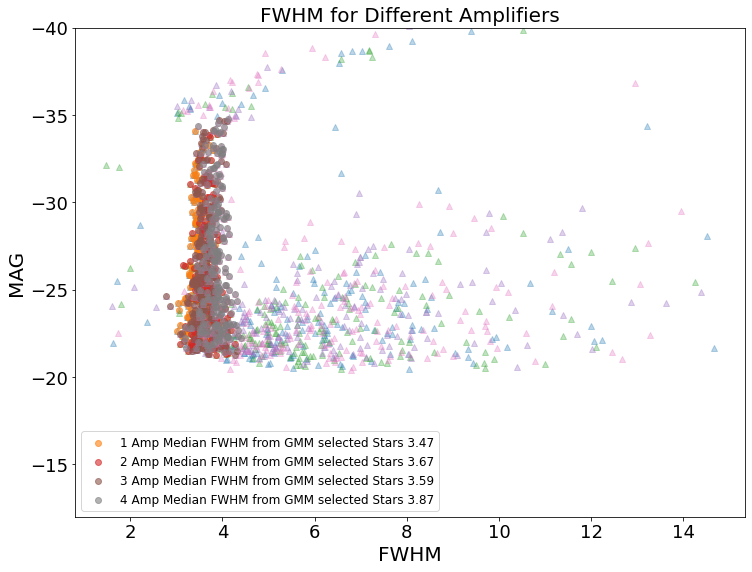

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 9)) 
plt.rc('axes', titlesize=20)      # Title font size
plt.rc('axes', labelsize=20)      # X/Y label font size
plt.rc('xtick', labelsize=18)     # X tick label font size
plt.rc('ytick', labelsize=18)     # Y tick label font size
plt.rc('legend', fontsize=12)     # Legend font size
plt.rc('figure', titlesize=22)    # Figure title font size
plt.rc('font', size=15)  
for ii in range(0,4):
    X= amp_cut(ii,all_objects)
    cuta = all_objects[cutt][labelst == 0]['subset_id']==ii
    plt.scatter(X[:,0],X[:,2],marker='^',alpha = 0.3)
    plt.scatter(all_objects[cutt][labelst == 0]['FWHM'][cuta],-2.5*np.log(all_objects[cutt][labelst == 0]['flux'][cuta]),marker = 'o',label = str(ii+1)+' Amp Median FWHM from GMM selected Stars '+str(np.round(median_fwhm[ii],2)),alpha=0.6)
#c=labels, cmap='coolwarm'
plt.xlabel("FWHM")
plt.ylabel("MAG")
plt.ylim(-12.,-40)
plt.title("FWHM for Different Amplifiers")
plt.legend()
plt.show()

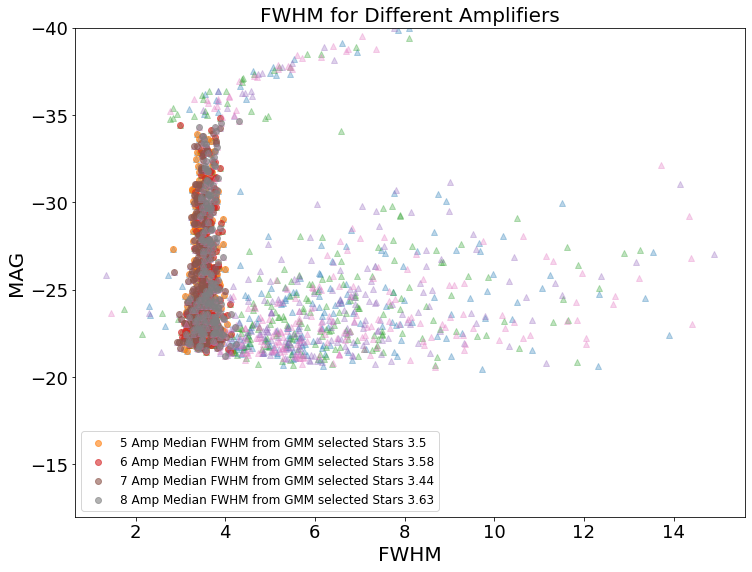

In [25]:
fig, ax = plt.subplots(figsize=(12, 9)) 
plt.rc('axes', titlesize=20)      # Title font size
plt.rc('axes', labelsize=20)      # X/Y label font size
plt.rc('xtick', labelsize=18)     # X tick label font size
plt.rc('ytick', labelsize=18)     # Y tick label font size
plt.rc('legend', fontsize=12)     # Legend font size
plt.rc('figure', titlesize=22)    # Figure title font size
plt.rc('font', size=15)  
for ii in range(4,8):
    X= amp_cut(ii,all_objects)
    cuta = all_objects[cutt][labelst == 0]['subset_id']==ii
    plt.scatter(X[:,0],X[:,2],marker='^',alpha = 0.3)
    plt.scatter(all_objects[cutt][labelst == 0]['FWHM'][cuta],-2.5*np.log(all_objects[cutt][labelst == 0]['flux'][cuta]),marker = 'o',label = str(ii+1)+' Amp Median FWHM from GMM selected Stars '+str(np.round(median_fwhm[ii],2)),alpha=0.6)
#c=labels, cmap='coolwarm'
plt.xlabel("FWHM")
plt.ylabel("MAG")
plt.ylim(-12.,-40)
plt.title("FWHM for Different Amplifiers")
plt.legend()
plt.show()

In [27]:
fwhm_fromi = fits.open('/Users/Jenny/projects/observation/bok/20250427/bs.OBJECT.0079_amp8_reduced.fits')

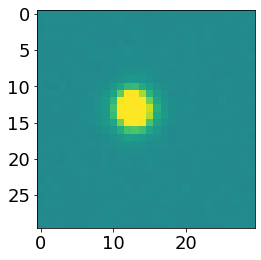

In [28]:

star_cut = fwhm_fromi[0].data[1860:1890,1550:1580]
plt.imshow(star_cut,vmin=0,vmax=5000)

In [29]:
max_idx = np.unravel_index(np.argmax(star_cut), star_cut.shape)

Text(0.5, 0, 'Counts')

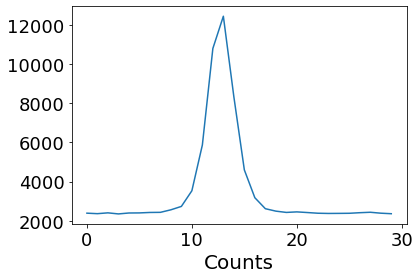

In [30]:
plt.plot(star_cut[max_idx[0],:])
plt.xlabel('Pixel')
plt.xlabel('Counts')

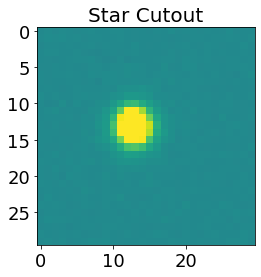

FWHM for this star: 4.00 pixels


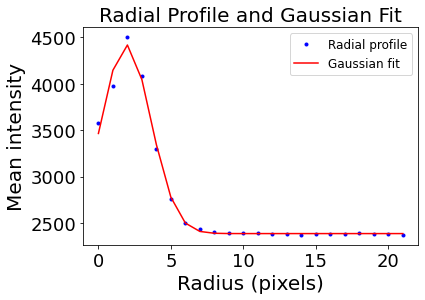

In [31]:
def gaussian(r, amp, mu, sigma, offset):
    return amp * np.exp(-0.5 * ((r - mu) / sigma)**2) + offset

def radial_profile(data, center=None):
    y, x = np.indices(data.shape)
    if center is None:
        center = (data.shape[0]//2, data.shape[1]//2)
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(int)
    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / np.maximum(nr, 1)
    return np.arange(len(radialprofile)), radialprofile

plt.imshow(star_cut, vmin=0, vmax=5000)
plt.title("Star Cutout")
plt.show()

# Calculate radial profile
rp_r, rp_flux = radial_profile(star_cut)

# Fit Gaussian to profile
p0 = [rp_flux.max(), 0, 2, np.median(rp_flux[-5:])]  # Initial guess
try:
    popt, _ = curve_fit(gaussian, rp_r, rp_flux, p0=p0)
    sigma = abs(popt[2])
    fwhm = 2.355 * sigma
    print(f"FWHM for this star: {fwhm:.2f} pixels")
    
    # Plot fit
    plt.plot(rp_r, rp_flux, 'b.', label='Radial profile')
    plt.plot(rp_r, gaussian(rp_r, *popt), 'r-', label='Gaussian fit')
    plt.xlabel('Radius (pixels)')
    plt.ylabel('Mean intensity')
    plt.title('Radial Profile and Gaussian Fit')
    plt.legend()
    plt.show()
except Exception as e:
    print("Fit failed:", e)

In [53]:
import tkinter as tk
import numpy as np

# Dummy data for demonstration; replace with your own arrays

cutt = cutt
 # For demonstration

class AmpGridGUI(tk.Tk):
    def __init__(self, all_objects, cutt, labelst):
        super().__init__()
        self.title("Amplifier Grid with Subgrids (Top 1-4, Bottom 5-8)")
        self.geometry("1500x900")
        self.all_objects = all_objects
        self.cutt = cutt
        self.labelst = labelst
        self.grid_mode = 1
        self.active_param = 'FWHM'

        # Control panel
        ctrl_frame = tk.Frame(self)
        ctrl_frame.pack(side=tk.TOP, pady=10)
        tk.Button(ctrl_frame, text="Show FWHM", font=("Arial", 14), command=lambda: self.show_param('FWHM')).pack(side=tk.LEFT, padx=10)
        tk.Button(ctrl_frame, text="Show Ellipticity", font=("Arial", 14), command=lambda: self.show_param('e')).pack(side=tk.LEFT, padx=10)
        tk.Label(ctrl_frame, text="Subgrids:", font=("Arial", 14)).pack(side=tk.LEFT, padx=5)
        self.grid_var = tk.IntVar(value=1)
        grid_menu = tk.OptionMenu(ctrl_frame, self.grid_var, 1, 2, 4, command=self.update_grid_mode)
        grid_menu.config(font=("Arial", 14), width=3)
        grid_menu.pack(side=tk.LEFT)

        self.amp_frame = tk.Frame(self)
        self.amp_frame.pack(side=tk.TOP, fill=tk.BOTH, expand=True)
        self.amp_panels = []
        self.show_param('FWHM')

    def update_grid_mode(self, value):
        self.grid_mode = int(value)
        self.show_param(self.active_param)

    def show_param(self, param):
        self.active_param = param
        for widget in self.amp_frame.winfo_children():
            widget.destroy()
        self.amp_panels.clear()
        grid_per_amp = self.grid_mode

        # Arrange amplifiers: 1-4 top row, 5-8 bottom row
        for amp in range(8):
            amp_outer_frame = tk.Frame(self.amp_frame, width=200, height=400, bd=4, relief=tk.RIDGE, bg="#cccccc")
            row = 0 if amp < 4 else 1
            col = amp if amp < 4 else amp - 4
            amp_outer_frame.grid(row=row, column=col, padx=5, pady=5, sticky="nsew")
            amp_outer_frame.grid_propagate(False)
            tk.Label(amp_outer_frame, text=f"Amp {amp+1}", font=("Arial", 16, "bold"), bg="#cccccc").pack(side=tk.TOP, pady=3)

            # Subgrid frame inside amplifier
            subgrid_frame = tk.Frame(amp_outer_frame, bg="#dddddd")
            subgrid_frame.pack(fill=tk.BOTH, expand=True, padx=5, pady=5)

            # Get amplifier-specific objects
            mask_amp = (self.all_objects['subset_id'][self.cutt] == amp)
            combined_mask = mask_amp & (self.labelst == 0)
            x = self.all_objects['x'][self.cutt][combined_mask]
            y = self.all_objects['y'][self.cutt][combined_mask]
            vals = self.all_objects[param][self.cutt][combined_mask]
            print (len(self.all_objects[param][self.cutt][ mask_amp]))

            if grid_per_amp == 1:
                median = np.median(vals) if len(vals) else np.nan
                N = len(vals)
                panel = tk.Frame(subgrid_frame, width=160, height=320, bd=2, relief=tk.GROOVE, bg="#eeeeee")
                panel.pack(fill=tk.BOTH, expand=True, padx=3, pady=3)
                tk.Label(panel, text=f"Median {param}:\n{median:.3f}", font=("Arial", 14), bg="#eeeeee").pack(pady=30)
                tk.Label(panel, text=f"N = {N}", font=("Arial", 13), bg="#eeeeee", fg="gray").pack(pady=5)
            elif grid_per_amp == 2:
                # Split y into top/bottom, 2 vertical panels
                if len(y):
                    ymid = 0.5 * (y.min() + y.max())
                    in_top = y < ymid
                    in_bottom = y >= ymid
                else:
                    in_top = in_bottom = np.zeros(0, dtype=bool)
                for split, mask in enumerate([in_top, in_bottom]):
                    med = np.median(vals[mask]) if np.sum(mask) else np.nan
                    N = np.sum(mask)
                    panel = tk.Frame(subgrid_frame, width=160, height=150, bd=2, relief=tk.GROOVE, bg="#f7f7f7")
                    panel.pack(fill=tk.BOTH, expand=True, padx=3, pady=3)
                    tk.Label(panel, text=f"{'Top' if split==0 else 'Bottom'}", font=("Arial", 12, "bold"), bg="#f7f7f7").pack(pady=2)
                    tk.Label(panel, text=f"{med:.3f}", font=("Arial", 13), bg="#f7f7f7").pack(pady=4)
                    tk.Label(panel, text=f"N = {N}", font=("Arial", 12), bg="#f7f7f7", fg="gray").pack(pady=2)
            elif grid_per_amp == 4:
                # Split into 2x2 grid (by x and y)
                if len(x) and len(y):
                    xbins = np.linspace(x.min(), x.max(), 3)
                    ybins = np.linspace(y.min(), y.max(), 3)
                else:
                    xbins = np.linspace(0, 1024, 3)
                    ybins = np.linspace(0, 1024, 3)
                for row2 in range(2):
                    for col2 in range(2):
                        in_panel = (
                            (x >= xbins[col2]) & (x < xbins[col2+1]) &
                            (y >= ybins[row2]) & (y < ybins[row2+1])
                        )
                        med = np.median(vals[in_panel]) if np.sum(in_panel) else np.nan
                        N = np.sum(in_panel)
                        panel = tk.Frame(subgrid_frame, width=70, height=70, bd=2, relief=tk.GROOVE, bg="#f7f7f7")
                        panel.grid(row=row2, column=col2, padx=2, pady=2, sticky="nsew")
                        tk.Label(panel, text=f"({['Top','Bottom'][row2]}-{['Left','Right'][col2]})", font=("Arial", 10, "bold"), bg="#f7f7f7").pack(pady=1)
                        tk.Label(panel, text=f"{med:.3f}", font=("Arial", 11), bg="#f7f7f7").pack(pady=2)
                        tk.Label(panel, text=f"N = {N}", font=("Arial", 10), bg="#f7f7f7", fg="gray").pack(pady=1)
                for i in range(2):
                    subgrid_frame.grid_rowconfigure(i, weight=1)
                    subgrid_frame.grid_columnconfigure(i, weight=1)

            self.amp_panels.append(amp_outer_frame)

        for i in range(4):
            self.amp_frame.grid_columnconfigure(i, weight=1)
        for i in range(2):
            self.amp_frame.grid_rowconfigure(i, weight=1)

if __name__ == "__main__":
    app = AmpGridGUI(all_objects, cutt, labelst)
    app.mainloop()

363
360
367
410
382
438
420
403


Exception in Tkinter callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.8/tkinter/__init__.py", line 1892, in __call__
    return self.func(*args)
  File "<ipython-input-52-db063d94d027>", line 23, in <lambda>
    tk.Button(ctrl_frame, text="Show FWHM", font=("Arial", 14), command=lambda: self.show_param('FWHM')).pack(side=tk.LEFT, padx=10)
  File "<ipython-input-52-db063d94d027>", line 66, in show_param
    print (len(self.all_objects['x'][param][self.cutt]))
  File "astropy/table/_column_mixins.pyx", line 81, in astropy.table._column_mixins._ColumnGetitemShim.__getitem__
  File "astropy/table/_column_mixins.pyx", line 64, in astropy.table._column_mixins.base_getitem
  File "astropy/table/_column_mixins.pyx", line 76, in astropy.table._column_mixins.column_getitem
IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Exception in Tkinter callback
Traceback (most recent call last):
 

363
360
367
410
382
438
420
403
